In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


os.makedirs('../images', exist_ok=True)
print("images/ folder ready")

images/ folder ready


In [54]:
telco = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

print(telco.head())
telco.shape

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

(7043, 21)

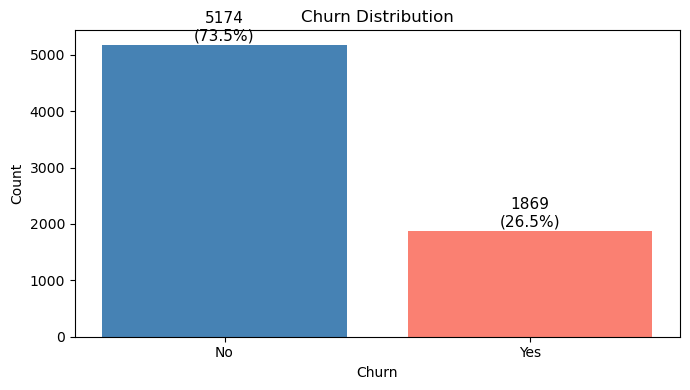

In [55]:
fig, ax = plt.subplots(figsize=(7, 4))

counts = telco['Churn'].value_counts()
percentages = telco['Churn'].value_counts(normalize=True) * 100

bars = ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'])

for bar, count, pct in zip(bars, counts.values, percentages.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count}\n({pct:.1f}%)",          
        ha='center', va='bottom', fontsize=11
    )

ax.set_title("Churn Distribution")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

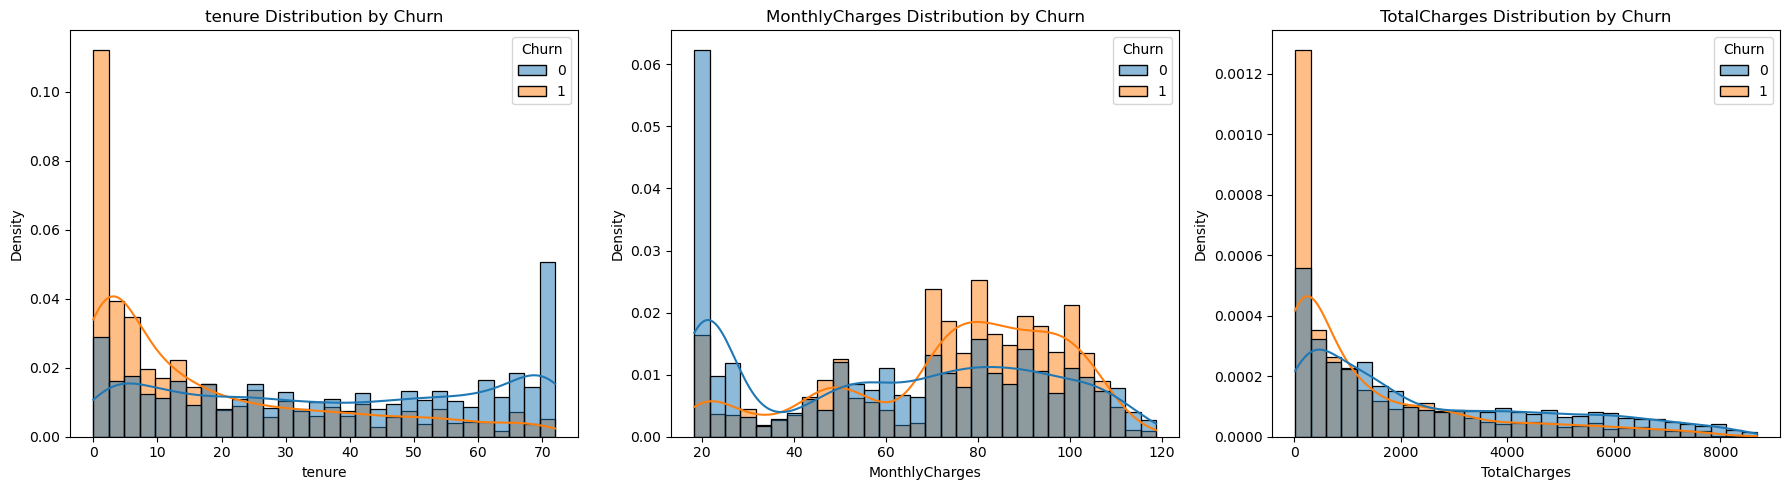

In [71]:
telco['TotalCharges'] = pd.to_numeric(telco['TotalCharges'], errors='coerce')

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, num_cols):
    sns.histplot(
        data=telco,
        x=col,
        hue='Churn',
        bins=30,
        kde=True,
        stat='density',
        common_norm=False,
        ax=ax
    )

    ax.set_title(f'{col} Distribution by Churn')

plt.tight_layout()
plt.show()

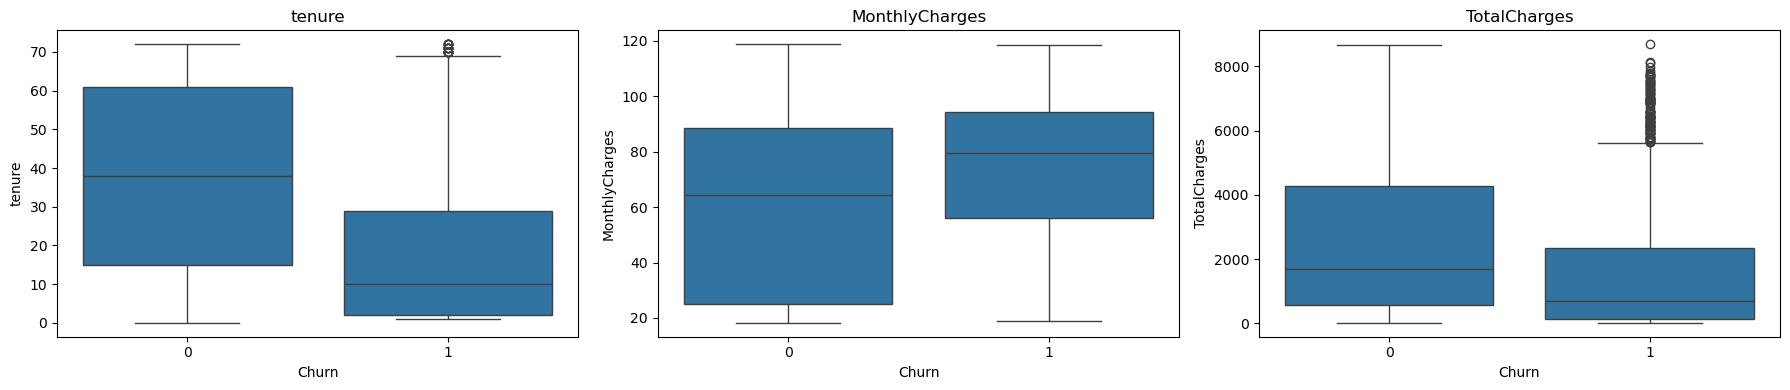

In [72]:

fig, axes = plt.subplots(1, 3, figsize=[18, 4])

for ax, col in zip(axes, num_cols):
    sns.boxplot(
        data=telco,
        x='Churn',
        y=col,
        ax=ax
    )

    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
telco['ChurnFlag'] = telco['Churn'].map({'No': 0, 'Yes': 1})
telco[['Churn', 'ChurnFlag']].head()

,Churn,ChurnFlag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


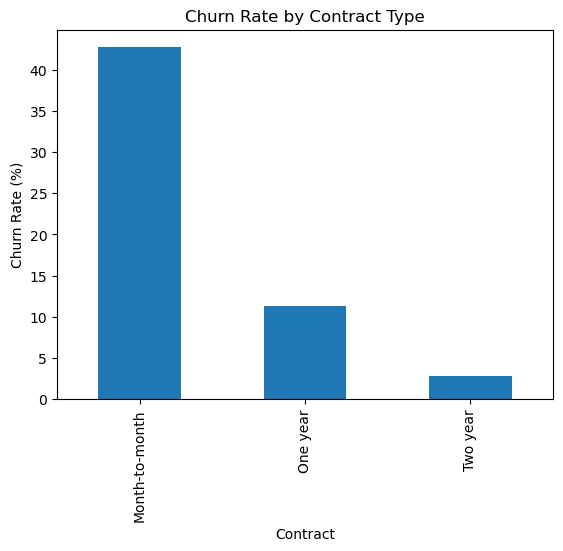

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: ChurnFlag, dtype: float64

In [ ]:
contract_churn = (
    telco.groupby('Contract')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.show()

contract_churn

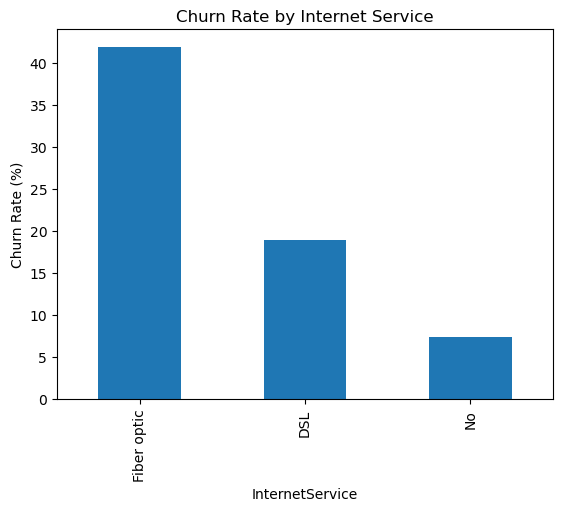

InternetService
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: ChurnFlag, dtype: float64

In [ ]:
internet_churn = (
    telco.groupby('InternetService')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

internet_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Internet Service')
plt.show()

internet_churn

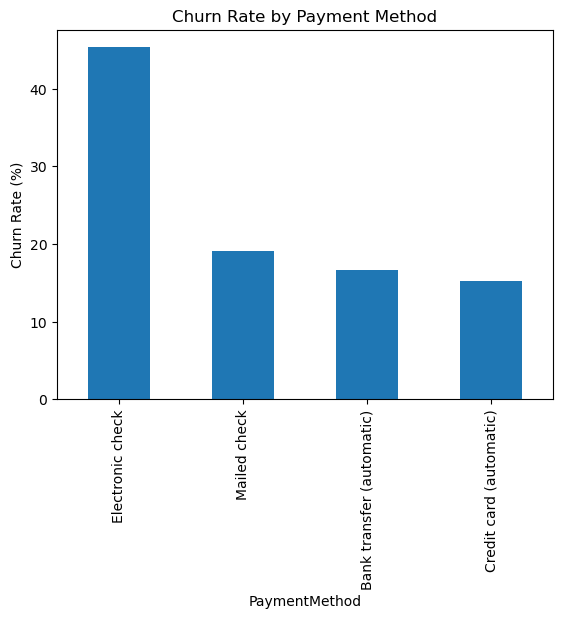

PaymentMethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: ChurnFlag, dtype: float64

In [ ]:
payment_churn = (
    telco.groupby('PaymentMethod')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

payment_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Payment Method')
plt.show()

payment_churn

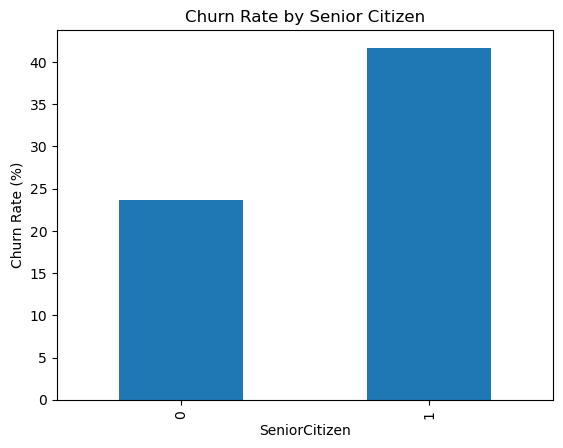

In [ ]:
senior_churn = (
    telco.groupby('SeniorCitizen')['ChurnFlag']
    .mean()
    .mul(100)
)

senior_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Senior Citizen')
plt.show()

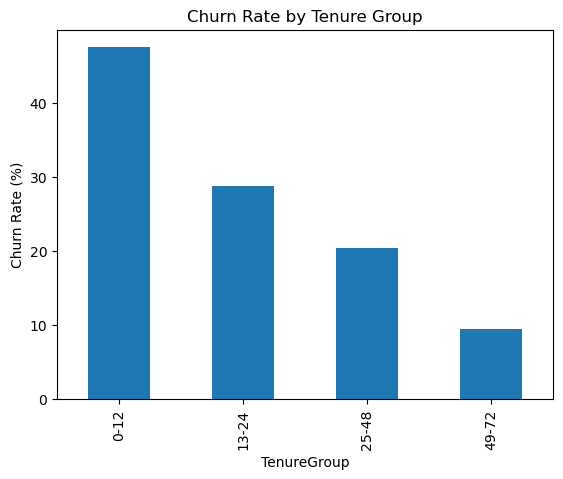

TenureGroup
0-12     47.438243
13-24    28.710938
25-48    20.388959
49-72     9.513176
Name: ChurnFlag, dtype: float64

In [ ]:
telco['TenureGroup'] = pd.cut(
    telco['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12', '13-24', '25-48', '49-72'],
    include_lowest=True
)

tenure_churn = (
    telco.groupby('TenureGroup')['ChurnFlag']
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

tenure_churn.plot(kind='bar')

plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Tenure Group')
plt.show()

tenure_churn

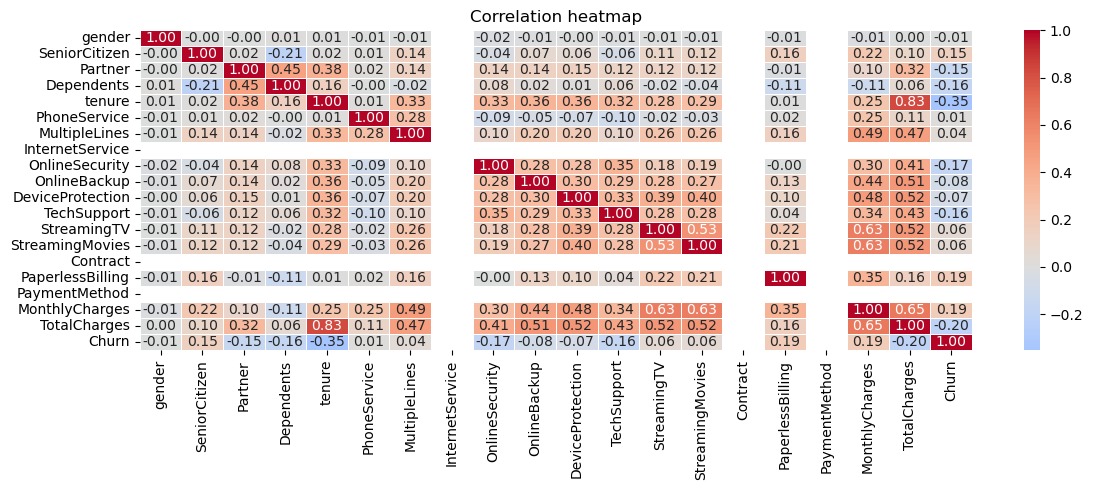

In [78]:
encode_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0,
              'No internet service': 0, 'No phone service': 0}

telco_corr = telco.copy()
for col in telco_corr.select_dtypes(include=['object', 'str']).columns:
    telco_corr[col] = telco_corr[col].map(encode_map)

corr = telco_corr.drop(columns=['customerID', 'TenureGroup'], errors='ignore').corr()

plt.figure(figsize=(12, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()
